In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import utils as ut

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Note

Most of this notebook was developed with reference to:

- https://www.youtube.com/watch?v=K--1hlv9yv0
- https://github.com/lukepolson/youtube_channel/blob/main/Python%20Metaphysics%20Series/vid14.ipynb

The reference implementation makes several simplifications for ease of explanation. This notebook extends it by

- including an external magnetic field in the Hamiltonian;
- correcting the convolution-based energy calculation;
- calculating the magnetisation and magnetic susceptibility.

as well as through other miscellaneous modifications.

# 1. Introductory Theory

### Canonical Distribution and Detailed Balance

Consider a system in thermal equilibrium with a heat bath at temperature $T$. The probability of finding the system in microstate $r$, with energy $E_r$, is

$$p_r = \frac{1}{Z}e^{-\beta E_r},$$

where $\beta = 1/(k_B T)$ and

$$Z=\sum_r e^{-\beta E_r}$$

is the **partition function**.

At equilibrium, probability flowing out of each state must balance probability flowing into it:

$$\sum_s p_r P(r\to s)=\sum_s p_s P(s\to r),$$

where $P(r\to s)$ is the transition probability from state $r$ to state $s$.

This condition is difficult to enforce directly in a numerical simulation. Instead, we impose the stronger **detailed balance condition**

$$p_rP(r\to s)=p_sP(s\to r).$$

Detailed balance guarantees that the Boltzmann distribution is an equilibrium distribution of the simulation.

### Ising Model

For the two-dimensional Ising model, the total energy of microstate $r$ is

$$E_r=-J\sum_{\langle i,j\rangle}\sigma_i\sigma_j-\mu_sB\sum_i\sigma_i.$$

Here:

- $\sigma_i=\pm1$ is the spin at lattice site $i$;
- $J$ is the nearest-neighbour interaction strength;
- $\langle i,j\rangle$ denotes pairs of nearest neighbours;
- $\mu_s$ is the magnetic moment of each spin;
- $B$ is the external magnetic field.

Using the Boltzmann probabilities in the detailed balance condition gives

$$\frac{P(r\to s)}{P(s\to r)}=\frac{p_s}{p_r}=e^{-\beta(E_s-E_r)}.$$

This relation forms the basis of the Metropolis algorithm.

### Metropolis Algorithm

The aim is to generate spin configurations according to the equilibrium Boltzmann distribution.

Start from some random lattice configuration and repeatedly propose single-spin flips.

1. Let $r$ be the current microstate.
2. Choose a random spin $\sigma_i$ and propose flipping it. Let $s$ be the resulting microstate.
3. Calculate the energy change

$$\Delta E=E_s-E_r.$$

4. Apply the Metropolis acceptance rule:
   - If $\Delta E\leq0$, the energy decreases, so **accept the flip**.
   - If $\Delta E>0$, the energy increases, so **accept the flip with probability $e^{-\beta\Delta E}$**.
5. Repeat many times. After sufficient equilibration, the generated configurations sample the equilibrium distribution.

The acceptance rule satisfies detailed balance.

If $E_s>E_r$, choose $P(s\to r)=1$. Detailed balance then requires

$$P(r\to s)=e^{-\beta(E_s-E_r)}.$$

If $E_s<E_r$, instead choose $P(r\to s)=1$, with the reverse transition occurring with the corresponding Boltzmann probability.

For a single-spin flip in the two-dimensional Ising model,

$$\Delta E=2\sigma_i\left(J\sum_{k=1}^{4}\sigma_k+\mu_sB\right),$$

where $\sigma_k$ are the four nearest neighbours of the flipped spin.

Periodic boundary conditions are used, so every lattice site has exactly four nearest neighbours.

### Dimensionless Form

It is convenient to express the simulation entirely in dimensionless quantities.

Measure energy in units of $J$:

$$\tilde E=\frac{E}{J}.$$

The Hamiltonian becomes

$$\tilde E=-\sum_{\langle i,j\rangle}\sigma_i\sigma_j-H\sum_i\sigma_i,$$

where

$$H=\frac{\mu_sB}{J}.$$

The Metropolis factor therefore becomes

$$e^{-\beta\Delta E}=e^{-\beta J\Delta\tilde E}.$$

For a proposed single-spin flip,

$$\Delta\tilde E=2\sigma_i\left(\sum_{k=1}^{4}\sigma_k+H\right).$$

Thus the implementation only needs to calculate $\Delta\tilde E$ for the chosen spin and apply

$$
\boxed{
\begin{cases}
\text{accept}, & \Delta\tilde E\leq0,\\
\text{accept with probability }e^{-\beta J\Delta\tilde E}, & \Delta\tilde E>0.
\end{cases}
}
$$

# 2. Simulation
### Parameters
The variables in this code block can be modified for different results. All other code blocks should not be modified.

In [3]:
L = 40 # number of spins in one side of the square lattice (so total there are N = L^2 spins)
ratio = 0.5 # ratio of positive to negative spins

# hamiltonian parameters
H = 0.0 # H = mu_s * B / J
BJ = 0.8

# metropolis parameters
num_sweeps = 300  # number of monte carlo sweeps = num_sweeps * N monte carlo iterations
save_every = L**2 # save snapshots of the lattice for animation every <save_every> monte carlo iteration

# initial portion of run to discard so only equilibrium states are considered for stats calculations
burn_in_fraction = 0.5 

### Basic Metropolis Simulation

In [4]:
# generate lattice of random spins
lattice = ut.generate_lattice(L, ratio)

Compute the dimensionless energy $$\tilde E_\mu = -\sum_{<i,j>}\sigma_i \sigma_j - H\sum_i\sigma_i$$
The interaction terms can be efficiently computed using convolutions. 

In [5]:
# compute energy of initial system
energy = ut.get_energy(lattice, H)
print(energy)

8.0


In [6]:
# execute algorithm
N = L**2
steps = N * num_sweeps
final_lattice, spins, energies, frames = ut.metropolis(lattice, steps, BJ, H, energy, save_every)

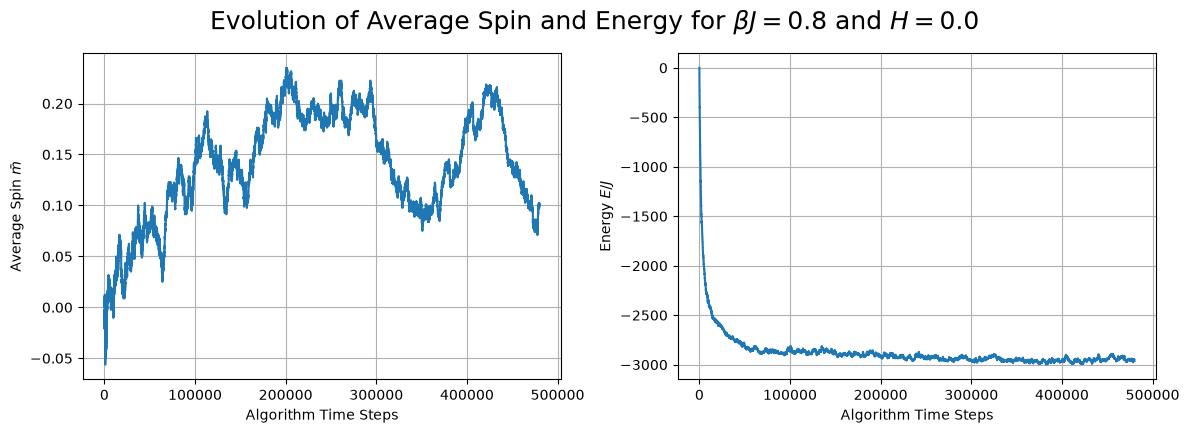

In [7]:
# plot evolution of average spin and energy
fig, axes = plt.subplots(1, 2, figsize=(12,4))
ax = axes[0]
ax.plot(spins/N)
ax.set_xlabel('Algorithm Time Steps')
ax.set_ylabel(r'Average Spin $\bar{m}$')
ax.grid()
ax = axes[1]
ax.plot(energies)
ax.set_xlabel('Algorithm Time Steps')
ax.set_ylabel(r'Energy $E/J$')
ax.grid()
fig.tight_layout()
fig.suptitle(rf'Evolution of Average Spin and Energy for $\beta J={BJ}$ and $H={H}$', y=1.07, size=18)
plt.show()

### Lattice Evolution Animation
The example in this notebook features an example of a limitation in the Metropolis algorithm. The simulation is more or less stuck with one half as `+1` and the other as `-1`, and the algorithm is not very good at getting out of this situation and stabilising to all `+1` or all `-1`.

In [ ]:
ut.make_gif(frames, "images/ising_evolution.gif", fps=16)

![Ising model evolution](images/ising_evolution.gif)

# 3. Observables
### Magnetisation

Magnetisation (average magnetic moment per spin) of a state $r$ is typically defined as

$$m_r = \frac{\mu_s}{N} \sum_i^{N} \sigma_i$$

To preserve our dimensionless approach, we will instead directly measure average spin

$$\tilde m_r = \frac1{N}\sum_i^{N} \sigma_i$$

where $\tilde m_r = m_r / \mu_s$.

In [10]:
start = int(burn_in_fraction * len(spins))

equilibrium_spins = spins[start:]
equilibrium_energies = energies[start:]

m = equilibrium_spins / N
mean_m = np.mean(m)
print(f'Magnetisation is {mean_m:.5f}')

Magnetisation is 0.15193


### Magnetic susceptibility

Magnetic susceptibility is defined as 

$$\chi := \frac{\partial\braket M}{\partial B}$$

An equivalent expression of $\chi$ is

$$\chi := \beta\ \text{Var}(M)$$

which is derived below:

<p align="center">
  <img src="images/derivation_of_chi.png" alt="derivation of magnetic susceptibility" width="600" align="center"/>
</p>

To maintain the dimensionless approach, magnetisation $m$ is converted to reduced magnetisation $\tilde m$ and susceptibility per spin is measured rather than over the whole system. 

<p align="center">
  <img src="images/convert_to_dimless.png" alt="conversion to dimensionless chi" width="600" align="center"/>
</p>

As per the above working, reduced susceptibility $\tilde\chi$ is given by

$$\tilde\chi:= BJN\ \text{Var}\left(\tilde m\right)$$

In [11]:
chi = BJ * N * (np.mean(m**2) - np.mean(m)**2)
print(f'Magnetic susceptibility is {chi:.5f}')

Magnetic susceptibility is 2.17206
